# Python + K-Space Playground
Hands-on mini-lab for MRI students learning basic Python *and* how k-space builds an image.
— **No prior coding assumed** —

### Learning goals
1. **Python essentials**: variables, arrays, loops, plotting
2. **K-space intuition**: see how a 2-D Fourier Transform turns frequency data into an image
3. Play with undersampling and observe aliasing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, interactive_output

%matplotlib inline

plt.rcParams['figure.figsize'] = (10,4)
plt.close('all')

## 1 ▸ Python crash
Run each cell (tweak the code when applicable) and observe the output

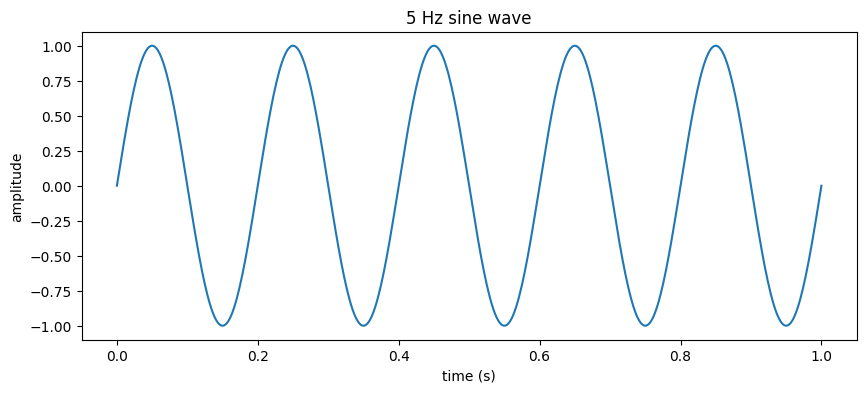

In [2]:
t = np.linspace(0, 1, 500) # Generates a vector of 500 values ranging from 0 to 1 (see what happens when you change these values)
f = 5 # Frequency of the sine wave in Hz
signal = np.sin(2*np.pi*f*t)
plt.plot(t, signal) # Sample the signal at the given time points
plt.title(str(f)+' Hz sine wave'); plt.xlabel('time (s)'); plt.ylabel('amplitude')
plt.show()

In [3]:
# Aliasing is a phenomenon that occurs when a signal is sampled at a rate that is insufficient to capture its frequency content.
# This can lead to distortion in the reconstructed signal, where higher frequency components are misrepresented as lower frequencies.

def aliasing_demo(phase=0, true_freq=5,num_samples=50):
    f=true_freq
    duration = 1  # Duration of the signal in seconds
    t1 = np.linspace(0, duration, 5000)
    t2 = np.linspace(0, duration, num_samples, endpoint=False)
    true_signal = np.sin((phase*np.pi)+2*np.pi*f*t1)
    sampled_signal = np.sin((phase*np.pi)+2*np.pi*f*t2)
    
    plt.plot(t1, true_signal, alpha=0.5, linewidth=3)
    plt.plot(t2, sampled_signal, c='r', marker='.', linestyle='--', linewidth=1.5, markersize=8)
    plt.plot([t2[-1],1], [sampled_signal[-1],sampled_signal[0]], c='grey', linestyle='--', linewidth=1.5)
    plt.plot(1, sampled_signal[0], c='grey', marker='.', markersize=8)
    
    apparent_f = 0 if num_samples == 2*f and (phase == 0 or phase == 2) else abs(((f + num_samples/2) % num_samples) - num_samples/2)
    
    plt.title(str(f)+' Hz signal looks like '+str(int(apparent_f))+' Hz'); plt.xlabel('time (s)'); plt.ylabel('amplitude')
    plt.show()

dem = interact(aliasing_demo, phase=(0, 2, 0.01), true_freq=(1, 50, 1), num_samples=(1, 200, 1))

for p in dem.widget.children:
    if isinstance(p, IntSlider) or isinstance(p, FloatSlider):
        p.style={'description_width': LABEL_W}
        if p.description == 'true_freq':
            p.description = 'True Frequency (Hz)'
            p.style.handle_color = 'lightblue'
            p.layout.width = f'calc(10em + 1.6*{LABEL_W})'
        elif p.description == 'num_samples':
            p.style.handle_color = 'red'
            p.layout.width = f'calc(40em + 1.6*{LABEL_W})'
        else:
            p.layout.width = f'calc(5em + 1.6*{LABEL_W})'
    
plt.close('all')

interactive(children=(FloatSlider(value=0.0, description='phase', max=2.0, step=0.01), IntSlider(value=5, desc…

NameError: name 'LABEL_W' is not defined

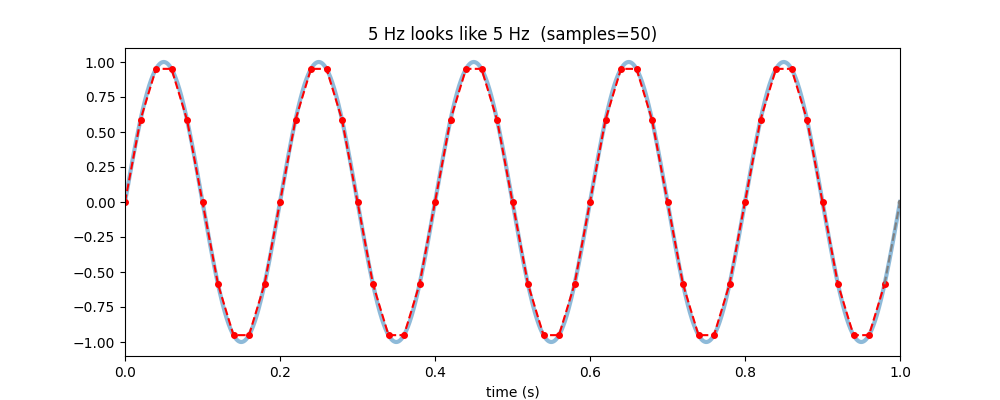

In [6]:
plt.close('all')

#%pip install ipympl
%matplotlib widget

import ipywidgets as widgets
from ipywidgets import FloatSlider, IntSlider, interactive_output

# Sliders
LABEL_W = '10em'
phase_slider = FloatSlider(description='phase (π rads)', min=0, max=2, step=0.01, value=0, layout=widgets.Layout(width=f'calc(5em + 1.6*{LABEL_W})'),  style={'description_width': LABEL_W})
freq_slider   = IntSlider(description='true_freq (Hz)', min=1, max=50, step=1, value=5, layout=widgets.Layout(width=f'calc(10em + 1.6*{LABEL_W})'), style={'description_width': LABEL_W})
samp_slider   = IntSlider(description='num_samples (per 1s)', min=1, max=200, step=1, value=50, layout=widgets.Layout(width=f'calc(40em + 1.6*{LABEL_W})'), style={'description_width': LABEL_W})

freq_slider.style.handle_color = 'lightblue'
samp_slider.style.handle_color = 'red'

# Single persistent figure
fig, ax = plt.subplots(figsize=(10,4))
line_true, = ax.plot([], [], alpha=.5, lw=3)
line_sample, = ax.plot([], [], 'r.--', lw=1.5, ms=8)
wrap_line, = ax.plot([], [], c='grey', ls='--')
wrap_dot, = ax.plot([], [], c='grey', marker='.')
ax.set_xlim(0,1); ax.set_ylim(-1.1,1.1); ax.set_xlabel('time (s)')
fig.canvas.header_visible = False
fig.canvas.footer_visible = False

def update(phase, freq_slider, samp_slider):
    f   = freq_slider
    Ns  = samp_slider

    t1 = np.linspace(0,1,5000)
    t2 = np.linspace(0,1,Ns,endpoint=False)
    y1 = np.sin(phase*np.pi + 2*np.pi*f*t1)
    y2 = np.sin(phase*np.pi + 2*np.pi*f*t2)

    line_true.set_data(t1, y1)
    line_sample.set_data(t2, y2)
    wrap_line.set_data([t2[-1], 1], [y2[-1], y2[0]])
    wrap_dot.set_data([1], [y2[0]])

    apparent = 0 if Ns == 2*f and phase in (0,2) else abs(((f+Ns/2)%Ns)-Ns/2)
    ax.set_title(f'{f} Hz looks like {int(apparent)} Hz  (samples={Ns})')
    fig.canvas.draw_idle()

# 4️⃣ Interactive binding
ui  = widgets.VBox([phase_slider, freq_slider, samp_slider])
out = interactive_output(update, {
        'phase'      : phase_slider,
        'freq_slider' : freq_slider,
        'samp_slider' : samp_slider
})
update(phase_slider.value, freq_slider.value, samp_slider.value)  # initial draw
widgets.VBox([ui, out])

---
## 2 ▸ What is **k-space**?
Think of the sine wave above. Frequency (k) lives in a different world than time (or position).  
In 2-D MRI we record a grid of frequencies (k_x, k_y). A 2-D Fourier Transform turns that grid into the spatial image we recognise.

### 2.1 Create a simple phantom image (circle)

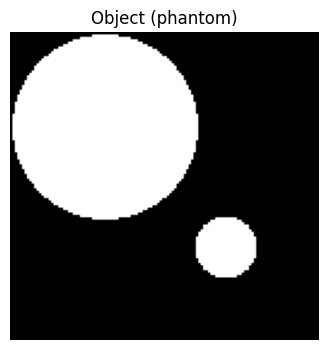

In [3]:
plt.close('all')
%matplotlib inline

def make_circle(N=128, radius=0.1, offset=0):
    y,x = np.indices((N,N))
    cx = cy = N//2 + offset
    r = np.sqrt((x-cx)**2 + (y-cy)**2)/N
    return (r < radius).astype(float)

phantom = make_circle(128, .1, 25)
phantom2 = make_circle(128, .3, -25)
plt.imshow(phantom+phantom2, cmap='gray'); plt.title('Object (phantom)'); plt.axis('off');

### 2.2 Compute its k-space

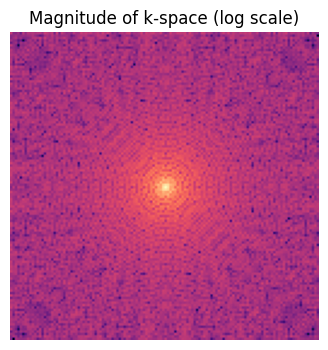

In [4]:
kspace = np.fft.fftshift(np.fft.fft2(phantom+phantom2))
plt.imshow(np.log(np.abs(kspace)+1e-3), cmap='magma')
plt.title('Magnitude of k-space (log scale)'); plt.axis('off');

### 2.3 Reconstruct by inverse FFT

(-0.5, 127.5, 127.5, -0.5)

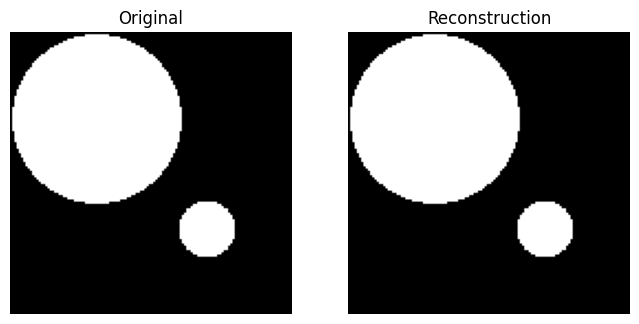

In [5]:
recon = np.abs(np.fft.ifft2(np.fft.ifftshift(kspace)))
fig,ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(phantom+phantom2, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(recon, cmap='gray');  ax[1].set_title('Reconstruction'); ax[1].axis('off')

## 3 ▸ Undersampling experiment
Slide the *fraction* of k-space lines we keep. Central lines = low frequencies ↔ overall shape; edges = fine detail.

In [6]:
def undersample_demo(center_frac=0.3):
    N = phantom.shape[0]
    width = int(center_frac * N / 2)
    mask = np.zeros_like(kspace, dtype=bool)
    mask[N//2-width:N//2+width, :] = True  # keep central lines
    k_us = np.where(mask, kspace, 0)
    recon = np.abs(np.fft.ifft2(np.fft.ifftshift(k_us)))
    fig,ax = plt.subplots(1,3,figsize=(12,4))
    ax[0].imshow(np.log(np.abs(k_us)+1e-3), cmap='magma'); ax[0].set_title('Sampled k-space'); ax[0].axis('off')
    ax[1].imshow(recon, cmap='gray'); ax[1].set_title('Recon'); ax[1].axis('off')
    ax[2].imshow(phantom+phantom2, cmap='gray'); ax[2].set_title('Ground truth'); ax[2].axis('off')
    plt.show()

interact(undersample_demo, center_frac=FloatSlider(0.3, min=0.05, max=1.0, step=0.05, description='center %'));

interactive(children=(FloatSlider(value=0.3, description='center %', max=1.0, min=0.05, step=0.05), Output()),…

### 4 ▸ Challenges
1. Modify `make_circle` to add a second smaller circle off-centre. How does that change k-space?
2. In the undersampling demo change the mask from central *lines* to a central *square*.
3. Try adding random noise to k-space before reconstruction. What happens to the image?